In [1]:
#!pip install numpy
#!pip install sklearn

In [2]:
import numpy as np
import sklearn as skl
import matplotlib.pyplot as plt

In [3]:
from IPython.core.display import HTML
HTML("""
<style>
.consignes{
  font-weight: bold;
  color: #3256a8;
  background-color: #edebdf
}
</style>
""")



# TP2: Détection de menaces radar

<div class=consignes> Listez les noms des étudiants (2 au maximum) ayant participé à ce notebook dans la cellule suivante (prénom, nom, affectation).<br/>
Au moment du rendu, le notebook doit être nommé nom1_nom2_dlts_tp2.ipynb 

2 séances de TP sur ce sujet : le 16 octobre (1h30) et le 23 octobre (3h).<br> 
Deadline : 30 otobre 2024, 13h59, par mail à deepetsignal.mva@gmail.com <br> 

Pour installer les paquets nécessaires à la réalisation de ce TP vous pouvez utiliser dans le notebook 
    
```
!pip install \< nom_du_paquet \>
```
merci de regrouper toutes les installations dans la première cellule du notebook. 
Essayez de faire en sorte que votre notebook puisse se lire comme un compte rendu, évitez de laisser du code mort et prennez le temps de commenter vos observations et résultats.
    
## Mission


Vous commandez un avion de reconnaissance en mission top secrète. Malgré votre discretion et toutes les précautions prises vous dérangez et pouvez être sujet de menaces qu'il vous faut détecter pour garantir la sécurité de votre équipage et la succès de votre mission (comme elle est top secrète vous ne pouvez pas en savoir plus). 

A votre disposition un réseau d'antennes et un système d'analyse spectrale perfectionnés vous permettent d'extraire et de caractériser des signaux en provenance des radars à altitude 0 qui parsèment votre parcours. 

Un signal radar est composé d'impulsions. Le système d'analyse vous permettent de caractériser chaque impulsion reçue par un PDW (Pulse Description Word) qui contient: 

- la date de début de détection de l'impulsion (en ms)
- la largeur ou durée de l'impulsion (en ms)
- la puissance de l'impulsion (en dB / référence) 
- l'angle theta et l'angle phi décrivant la direction dans laquelle l'impulsion est détectée (en radians)
- la fréquence de l'impulsion (en Ghz)

Votre capteur n'est pas parfait et vous subissez notamment un phénomène de mitage: une certaine proportion des impulsions émises ne sont pas détectées. Cette proportion est d'autant plus grande que la puissance des impulsions est petite.  

Votre vaisseau navigue à 10 km d'altitude, avec une vitesse constante de 1000 km/h vers le nord. 

De précédentes missions ont permis de réaliser une base de données de signaux de 10 secondes. 
Chaque signal se présente sous la forme d'un fichier .npz qui contient l'ensemble des PDW reçus. 

Un signal est donc un fichier dont le nom est de la forme 'pdw_<numéro du signal>.npz'.

Cette base de données est annotée: le destin de chaque mission a permis de déclarer chaque signal comme une 'menace' ou une 'nonmenace'. 

Les signaux ont été divisés en deux ensembles indépendants: 
    
- train
- test 
 
Les annotations pour chaque ensemble sont disponibles dans le fichier labels_<train ou test>.json qui donne l'association nom de fichier -> menace ou nonmenace. 
    
    
Votre mission (si vous l'acceptez) est de choisir et d'entrainer un algorithme d'apprentissage machine à détecter les menaces sur l'ensemble 'train' et à évaluer ses performances sur l'ensemble 'test'. 

Fort de votre expérience passée, vous décidez de suivre la méthodologie suivante: 

- Visualisation et analyse des données pour trouver les paramètres les plus pertinents à utiliser 
- Sélection d'un algorithme naïf "baseline" de référence: vous définissez un premier algorithme simple et caractérisez ses performances qui serviront de point de comparaison pour qualifier l'apport d'algorithmes plus sophistiqués 
- Vous utilisez la bibliothèque sklearn et notamment ses implémentations d'algorithmes de classification binaire pour définir et entrainer sur l'ensemble 'train' un ou plusieurs algorithmes en capacité de prédire le label menance ou nonmenace de chaque signal (https://scikit-learn.org/stable/auto_examples/classification/plot_classifier_comparison.html)
- Vous qualifiez les performances de vos algorithmes en termes d'accuracy (https://scikit-learn.org/stable/modules/generated/sklearn.metrics.accuracy_score.html#sklearn.metrics.accuracy_score) ; vous calculez aussi les matrices de confusion (https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html#sklearn.metrics.confusion_matrix)
    
Pour ce TP nous ne cherchons pas à mettre en place des algorithmes d'apprentissage profond. Ces méthodes pourront être investiguées dans un deuxième temps.
    
 Si les résultats vous semblent décevants, souvenez vous des conseils de votre prédecesseur et mentor G. Abitbol: "toujours donner un coup de pouce à un algo de machine learning  en lui présentant les bonnes données"

Vous pouvez ouvrir un fichier de la façon suivante:

</div>    

In [4]:
pdws = np.load('./radars/train/pdw-0.npz')
dates = pdws['date']
largeurs = pdws['largeur']
frequences=pdws['frequence']
puissances = pdws['puissance']
theta = pdws['theta']
phi = pdws['phi']

<div class=consignes> et les fichiers d'annotations:</div>

In [5]:
import json

with open('./radars/train_labels.json') as f: 
    dict_labels = json.load(f)

for i in range(10):
    print(f"Le signal pdw-{i}.npz est de type: {dict_labels[f'pdw-{i}']}")

Le signal pdw-0.npz est de type: nonmenace
Le signal pdw-1.npz est de type: nonmenace
Le signal pdw-2.npz est de type: menace
Le signal pdw-3.npz est de type: nonmenace
Le signal pdw-4.npz est de type: nonmenace
Le signal pdw-5.npz est de type: menace
Le signal pdw-6.npz est de type: menace
Le signal pdw-7.npz est de type: menace
Le signal pdw-8.npz est de type: menace
Le signal pdw-9.npz est de type: nonmenace


<div class=consignes> On compte sur vous, bonne chance ! </div>

## Data Analysis

In this section, we will try to look at the distribution of our data between the two labels "Menace" and "Non Menace" and try to identify some differences

### General Analysis

In the general analysis, we will concatenate all values and compute histogram to start identifying some patterns

In [6]:
import pandas as pd

def create_pdw_dataframe(set_type, json_label_path, pdw_folder='./radars'):

    with open(json_label_path, 'r') as f:
        labels = json.load(f)

    data_list = []
    for pdw_file, menace in labels.items():
      pdw_path = f"{pdw_folder}/{set_type}/{pdw_file}.npz"
      pdw_data = np.load(pdw_path)

      dates = pdw_data['date']
      largeurs = pdw_data['largeur']
      frequences = pdw_data['frequence']
      puissances = pdw_data['puissance']
      theta = pdw_data['theta']
      phi = pdw_data['phi']

      is_menace = (menace == 'menace')

      data_list.append({
          'date': dates,
          'largeur': largeurs,
          'frequence': frequences,
          'puissance': puissances,
          'theta': theta,
          'phi': phi,
          'menace': is_menace
      })

    df = pd.DataFrame(data_list)
    return df

In [7]:
train_df = create_pdw_dataframe(set_type='train', pdw_folder='./radars', json_label_path='./radars/train_labels.json')
train_df.head()

,date,largeur,frequence,puissance,theta,phi,menace
0,"[1.31, 24.985, 36.823, 66.42, 104.897, 122.655...","[0.291, 0.291, 0.293, 0.292, 0.291, 0.291, 0.2...","[2.2220113463017723, 2.1887378825919477, 2.204...","[-125.58248735699023, -133.03972100969634, -14...","[0.9578859532471261, 0.7757236420828455, 0.823...","[1.678935775441994, 1.8065992324090079, 1.3807...",False
1,"[3.72, 19.312, 24.814, 31.234, 40.408, 42.241,...","[0.138, 0.136, 0.138, 0.136, 0.138, 0.138, 0.1...","[3.011221070570557, 3.0262794017444095, 3.0064...","[-127.176799666022, -127.7514938922165, -127.2...","[2.7962717807754327, 3.100138202337863, 2.9741...","[1.5296932038533972, 1.7187292927487223, 1.709...",False
2,"[3.134, 26.803, 34.692, 39.427, 41.004, 44.160...","[0.201, 0.202, 0.203, 0.203, 0.202, 0.201, 0.2...","[0.9919904643038369, 0.9857211081518096, 0.986...","[-149.880060930416, -150.7680964513681, -150.6...","[-2.0412578355641227, -1.772373907923867, -1.7...","[1.6722396416013094, 1.6344171451080796, 1.600...",True
3,"[3.688, 14.634, 16.686, 18.056, 19.42300000000...","[0.068, 0.069, 0.069, 0.068, 0.068, 0.068, 0.0...","[1.6664240172021985, 1.6661103360176772, 1.662...","[-135.68775777002037, -134.50842919556754, -13...","[-2.621701006244045, -2.213762179939454, -2.70...","[1.4039557266900524, 1.488975965035762, 1.4761...",False
4,"[23.056, 51.203, 52.86, 59.483000000000004, 67...","[0.324, 0.324, 0.323, 0.325, 0.324, 0.325, 0.3...","[2.2078093931871146, 2.1930003703996603, 2.201...","[-172.60362010919195, -160.93505826531094, -16...","[2.274032092616462, 2.283569519382397, 2.15701...","[1.6134753329852611, 1.2039061221285539, 1.764...",False


We loaded the train dataset and stored in a pandas Dataframe so that we can easily compute and plot values.

In [8]:
from ipywidgets import interact

def plot_histogram_for(df, column, ax=None):
    if ax is None:
        plt.figure(figsize=(8, 6))
    
    df[~df['menace']][column].explode().hist(bins=50, alpha=0.5, label='Non Menace', ax=ax)
    df[df['menace']][column].explode().hist(bins=50, alpha=0.5, label='Menace', ax=ax)

    if ax is None:
        plt.xlabel(column)
        plt.ylabel('Count')
        plt.title(f'Histogram of {column} based on label')
        plt.legend()
    else:
        ax.set_xlabel(column)
        ax.set_ylabel("Count")
        ax.set_title(f'Histogram of {column} based on label')
        ax.legend()

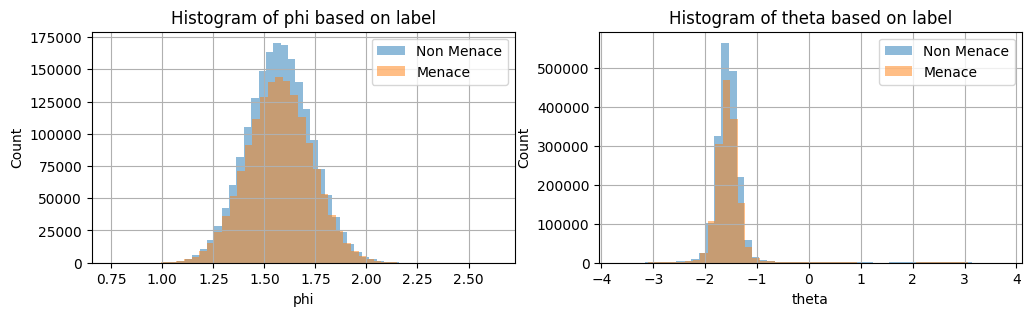

In [9]:
f, axes = plt.subplots(1, 2, figsize=(12, 3))
plot_histogram_for(train_df, "phi", axes[0])
plot_histogram_for(train_df, "theta", axes[1])
f.show()

From the above observations we can see that angles phi and theta follows a very similar distribution between "Menance" and "Non Menace"

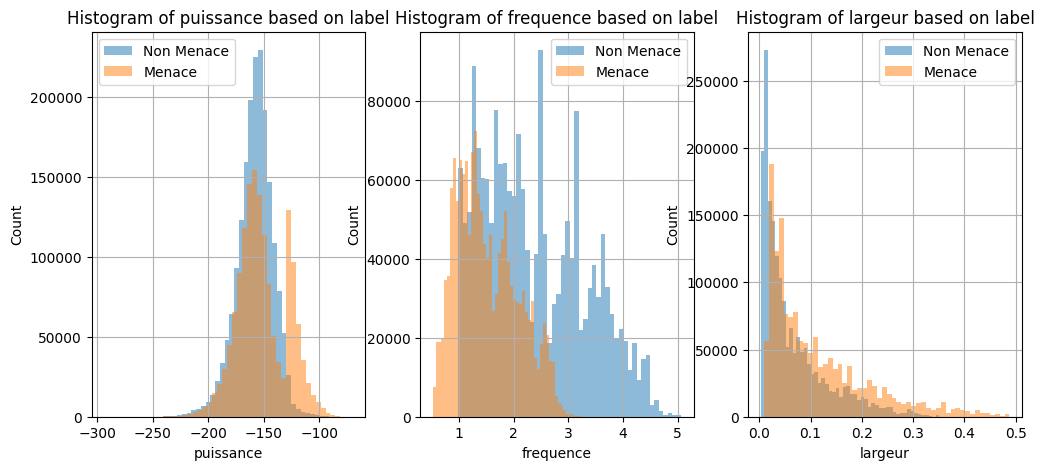

In [10]:
f, axes = plt.subplots(1, 3, figsize=(12, 5))
plot_histogram_for(train_df, "puissance", axes[0])
plot_histogram_for(train_df, "frequence", axes[1])
plot_histogram_for(train_df, "largeur", axes[2])
f.show()

However, frequency, power and width have different distributions between the two labels. We can therefore try to compute, mean, std, and other statistics and compare their histograms

### In Depth Analysis

The largest difference in histogram appears in the frequencies. Let's plot the mean and standard deviation of the signals frequencies

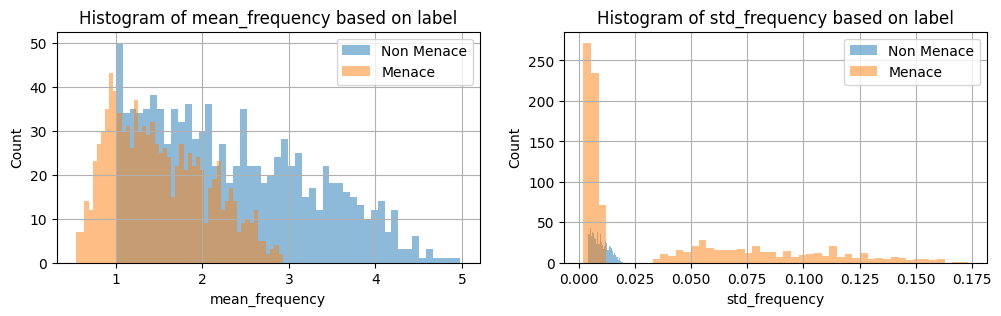

In [11]:
train_df["mean_frequency"] = train_df["frequence"].apply(np.mean)
train_df["std_frequency"] = train_df["frequence"].apply(np.std)

f, axes = plt.subplots(1, 2, figsize=(12, 3))
plot_histogram_for(train_df, "mean_frequency", axes[0])
plot_histogram_for(train_df, "std_frequency", axes[1])

Using the std frequency we can propose a first naive solution to cut at around 0.02 for the standard deviation and keep a mean frequency of 3

## Naive solution

As we already have found a way to separate "Non Menace" and "Menace" using the frequencies statistics, in this section we will implement the above threshold as our baseline solution to the predictions

In [12]:
import sklearn.metrics
from ipywidgets import fixed

# Load data
test_df = create_pdw_dataframe(set_type='test', pdw_folder='./radars', json_label_path='./radars/test_labels.json')
test_df["mean_frequency"] = test_df["frequence"].apply(np.mean)
test_df["std_frequency"] = test_df["frequence"].apply(np.std)

In [13]:
def thresholding_classification(df, mean_frequency_threshold=3.0, std_frequency_treshold=0.02):
    
    predictions = (df["mean_frequency"] < mean_frequency_threshold) & (df["std_frequency"] > std_frequency_treshold)
    Y_test = df["menace"]
    labels = ["Non Menace", "Menace"]
    
    print(sklearn.metrics.classification_report(Y_test, predictions, target_names=labels))
    sklearn.metrics.ConfusionMatrixDisplay.from_predictions(
        Y_test, predictions,
        display_labels=labels,
    )
    plt.title("Confusion Matrix for thresholding")
    plt.show()

interact(thresholding_classification, df=fixed(test_df), mean_frequency_threshold=(0, 5, 0.5), std_frequency_treshold=(0, 0.15, 0.01))

interactive(children=(FloatSlider(value=3.0, description='mean_frequency_threshold', max=5.0, step=0.5), Float…

<function __main__.thresholding_classification(df, mean_frequency_threshold=3.0, std_frequency_treshold=0.02)>

By interacting with the sliders, we can see that the best accuracy is acheived when mean frequency is around 3 and std frequency is around 0.02 as expected.

We already obtain a pretty good working solution on our test set, with a 71% accuracy (which is better than random >50%). However, thresholding by hand can get quite difficult to obtain better results. Moreover, if we increase the number of features, finding a good threhsold by hand is not efficient and not the best approach. We can improve our current results by computing more features and use machine learning.

# Machine Learning Approach

Following the above experiment, we can compute more statistics (mean, skew, kurtosis, ...) for all features obtained for a given signal. This features can be then given to a machine learning model to obtain better predictions.

## Load Dataset

This time we will load the dataset differently. We will keep using pandas, however we will directly compute features and stored them in the dataframe directly.

In [14]:
import pandas as pd
from scipy.stats import skew, kurtosis
from scipy.fftpack import fft
from scipy.signal import find_peaks

def compute_features_from_signal(pdws):
    features = {}

    # Extract information
    dates = pdws['date']
    bandwidth = pdws['largeur']
    frequency = pdws['frequence']
    power = pdws['puissance']
    theta = pdws['theta']
    phi = pdws['phi']

    # Bandwidth features
    features['mean_bandwidth'] = np.mean(bandwidth)
    features['std_bandwidth'] = np.std(bandwidth)
    features['min_bandwidth'] = np.min(bandwidth)
    features['max_bandwidth'] = np.max(bandwidth)
    features['skew_bandwidth'] = skew(bandwidth)
    features['kurtosis_bandwidth'] = kurtosis(bandwidth)
    
    # Power features
    features['mean_power'] = np.mean(power)
    features['std_power'] = np.std(power)
    features['min_power'] = np.min(power)
    features['max_power'] = np.max(power)
    features['skew_power'] = skew(power)
    features['kurtosis_power'] = kurtosis(power)
    features['power_above_75th'] = np.sum(power > np.percentile(power, 75)) / len(power)
    
    # Trend of power (linear fit)
    slope_power = np.polyfit(dates, power, 1)[0]
    features['slope_power'] = slope_power
    
    # Power FFT analysis
    fft_power = np.abs(fft(power))
    features['spectral_entropy_power'] = -np.sum(fft_power * np.log(fft_power + 1e-10))
    
    # Frequency features
    features['mean_frequency'] = np.mean(frequency)
    features['std_frequency'] = np.std(frequency)
    features['min_frequency'] = np.min(frequency)
    features['max_frequency'] = np.max(frequency)
    features['skew_frequency'] = skew(frequency)
    features['kurtosis_frequency'] = kurtosis(frequency)
    
    # Trend of frequency
    slope_frequency = np.polyfit(dates, frequency, 1)[0]
    features['slope_frequency'] = slope_frequency
    
    # Theta and Phi features (angular measures)
    features['mean_theta'] = np.mean(theta)
    features['std_theta'] = np.std(theta)
    features['min_theta'] = np.min(theta)
    features['max_theta'] = np.max(theta)
    
    # Circular mean and variance for theta
    features['circular_mean_theta'] = np.angle(np.mean(np.exp(1j * theta)))
    features['circular_variance_theta'] = 1 - np.abs(np.mean(np.exp(1j * theta)))

    features['mean_phi'] = np.mean(phi)
    features['std_phi'] = np.std(phi)
    features['min_phi'] = np.min(phi)
    features['max_phi'] = np.max(phi)
    
    # Circular mean and variance for phi
    features['circular_mean_phi'] = np.angle(np.mean(np.exp(1j * phi)))
    features['circular_variance_phi'] = 1 - np.abs(np.mean(np.exp(1j * phi)))

    # Angle rate of change
    delta_theta = np.diff(theta) / np.diff(dates)
    features['mean_rate_change_theta'] = np.mean(delta_theta)
    features['std_rate_change_theta'] = np.std(delta_theta)
    
    delta_phi = np.diff(phi) / np.diff(dates)
    features['mean_rate_change_phi'] = np.mean(delta_phi)
    features['std_rate_change_phi'] = np.std(delta_phi)
    
    # SNR (Signal-to-Noise Ratio)
    features['SNR'] = np.mean(power) / (np.std(power) + 1e-10)
    
    # Time-weighted averages (exponential decay with alpha=0.1)
    alpha = 0.1
    weights = np.exp(-alpha * (dates - dates[0]))
    weighted_mean_power = np.sum(weights * power) / np.sum(weights)
    features['weighted_mean_power'] = weighted_mean_power
    
    # Zero-crossing rates
    zero_crossings_power = np.sum(np.diff(np.sign(power - np.mean(power))) != 0)
    features['zero_crossing_rate_power'] = zero_crossings_power / len(power)
    
    return features



def load_dataset(dict_labels, split):
    data = []
    for i in range(len(dict_labels)):
        file_name = f'pdw-{i}'
        label = dict_labels[file_name]
        pdws = np.load(f'./radars/{split}/{file_name}.npz')
    
        signal_statistics = compute_features_from_signal(pdws)
        signal_statistics["label"] = label
        data.append(signal_statistics)
    
    df = pd.DataFrame(data)

    return df


with open('./radars/train_labels.json') as f: 
    train_dict_labels = json.load(f)

with open('./radars/test_labels.json') as f: 
    test_dict_labels = json.load(f)

train_df = load_dataset(train_dict_labels, "train")
test_df = load_dataset(test_dict_labels, "test")

Now that both train and test dataframes containing features are loaded. We can plot the additional features and see if the proposed additional features can have an impact on the model performance.

In [24]:
from ipywidgets import interact

def plot_histogram_for(df, column):
    plt.figure(figsize=(8, 6))
    
    df[df['label'] == "nonmenace"][column].hist(bins=10, alpha=0.5, label='Non Menace')
    df[df['label'] == "menace"][column].hist(bins=10, alpha=0.5, label='Menace')
    
    plt.xlabel(column)
    plt.ylabel('Frequency')
    plt.title(f'Histogram of {column} based on label')
    plt.legend()

interact(lambda column_name: plot_histogram_for(train_df, column_name), column_name=train_df.columns)

interactive(children=(Dropdown(description='column_name', options=('mean_bandwidth', 'std_bandwidth', 'min_ban…

<function __main__.<lambda>(column_name)>

## Training a model

Now that our features are defined, we will try to train multiple ML models such as:

* Logistic Regression
* SVM
* Random Forest

We will than compare their results using the accuracy score.

In [16]:
seed = 42 # Let's fix the seed

In [17]:
labels = ["Non Menace", "Menace"]

X_train, Y_train = train_df.drop(["label"], axis=1), train_df["label"] == "menace"
X_test, Y_test = test_df.drop(["label"], axis=1), test_df["label"] == "menace"

### Logistic Regression

              precision    recall  f1-score   support

  Non Menace       0.78      0.79      0.79       415
      Menace       0.77      0.76      0.77       385

    accuracy                           0.78       800
   macro avg       0.78      0.78      0.78       800
weighted avg       0.78      0.78      0.78       800



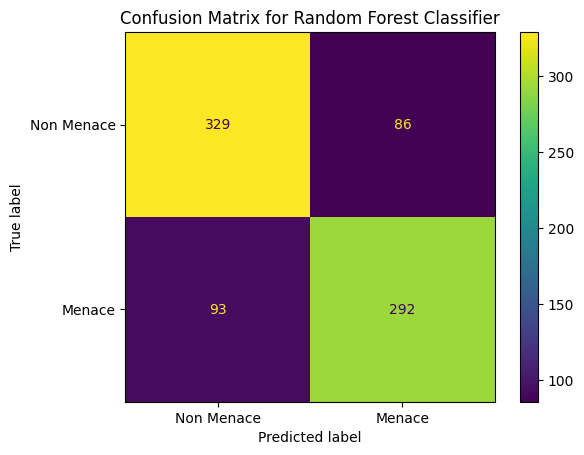

In [18]:
import sklearn.metrics
import sklearn.linear_model

clf = sklearn.linear_model.LogisticRegression(random_state=seed, max_iter=5000).fit(X_train, Y_train)
predictions = clf.predict(X_test)

print(sklearn.metrics.classification_report(Y_test, predictions, target_names=labels))
sklearn.metrics.ConfusionMatrixDisplay.from_predictions(
    Y_test, predictions,
    display_labels=labels,
)
plt.title("Confusion Matrix for Random Forest Classifier")
plt.show()

The logistic regression already proposde an improvement upon the thresholding method we used. We reach an accuracy score of 78% (>71%)!

### SVM

              precision    recall  f1-score   support

  Non Menace       0.54      0.55      0.55       415
      Menace       0.51      0.49      0.50       385

    accuracy                           0.53       800
   macro avg       0.52      0.52      0.52       800
weighted avg       0.52      0.53      0.52       800



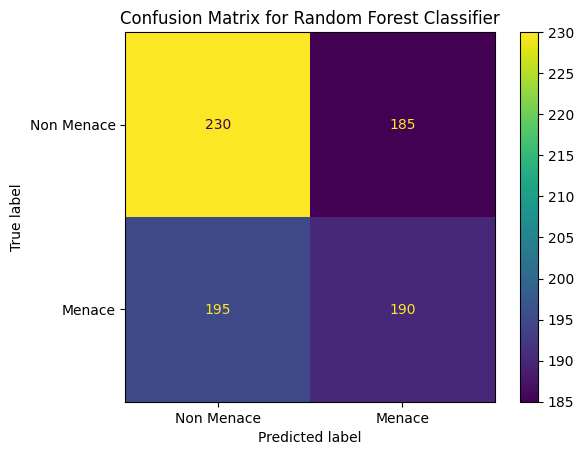

In [19]:
import sklearn.metrics
import sklearn.svm

clf = sklearn.svm.SVC(random_state=seed).fit(X_train, Y_train)
predictions = clf.predict(X_test)

print(sklearn.metrics.classification_report(Y_test, predictions, target_names=labels))
sklearn.metrics.ConfusionMatrixDisplay.from_predictions(
    Y_test, predictions,
    display_labels=labels,
)
plt.title("Confusion Matrix for Random Forest Classifier")
plt.show()

The SVM approach is not able to classify our signals with the provided features. We obtain an accuracy score no better than random.

### Random Forest

              precision    recall  f1-score   support

  Non Menace       0.83      0.93      0.88       415
      Menace       0.92      0.79      0.85       385

    accuracy                           0.86       800
   macro avg       0.87      0.86      0.86       800
weighted avg       0.87      0.86      0.86       800



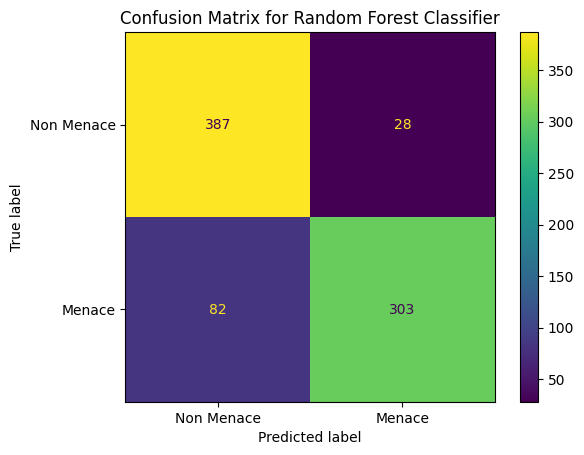

In [20]:
import sklearn.metrics
import sklearn.ensemble

clf = sklearn.ensemble.RandomForestClassifier(random_state=seed).fit(X_train, Y_train)
predictions = clf.predict(X_test)

print(sklearn.metrics.classification_report(Y_test, predictions, target_names=labels))
sklearn.metrics.ConfusionMatrixDisplay.from_predictions(
    Y_test, predictions,
    display_labels=labels,
)
plt.title("Confusion Matrix for Random Forest Classifier")
plt.show()

Random Forest works very great on our dataset, we reach an accuracy of 86% (>75%) which is even better than the logistic regression.
An additional advantage of RF is that we can compute some feature importances and check if some of our hypotesis are seen in the feature importances.

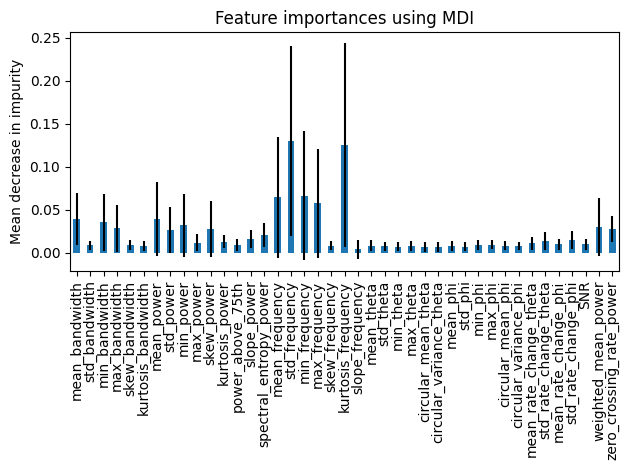

In [21]:
importances = clf.feature_importances_
std = np.std([tree.feature_importances_ for tree in clf.estimators_], axis=0)

forest_importances = pd.Series(importances, index=train_df.drop(["label"], axis=1).columns)

fig, ax = plt.subplots()
forest_importances.plot.bar(yerr=std, ax=ax)
ax.set_title("Feature importances using MDI")
ax.set_ylabel("Mean decrease in impurity")
fig.tight_layout()

Using trees, we can see the feature importance for the tree, as expected angles features are not important to solve the problem, whereas frequency information has a great importance.

## Grid Search

We can try to optimize the hyperparameters of our best performing model to reach greater performance

Fitting 3 folds for each of 48 candidates, totalling 144 fits
              precision    recall  f1-score   support

  Non Menace       0.83      0.93      0.88       415
      Menace       0.91      0.80      0.85       385

    accuracy                           0.86       800
   macro avg       0.87      0.86      0.86       800
weighted avg       0.87      0.86      0.86       800



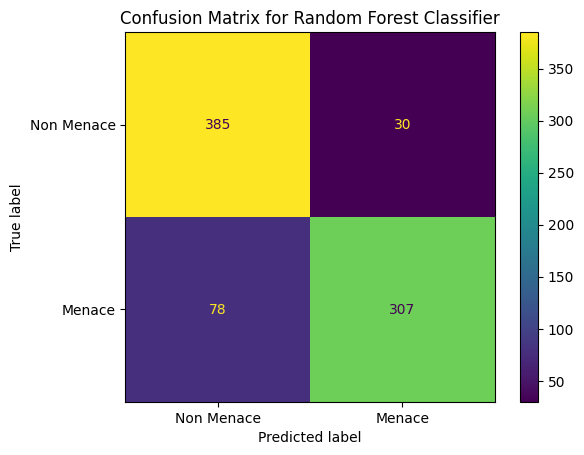

In [22]:
from sklearn.model_selection import GridSearchCV

param_distributions = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2'],
    'bootstrap': [True]
}

grid_search = GridSearchCV(estimator=sklearn.ensemble.RandomForestClassifier(random_state=seed),
                           param_grid=param_distributions,
                           cv=3,
                           n_jobs=-1,
                           verbose=2)

grid_search.fit(X_train, Y_train)

predictions = grid_search.predict(X_test)

print(sklearn.metrics.classification_report(Y_test, predictions, target_names=labels))
sklearn.metrics.ConfusionMatrixDisplay.from_predictions(
    Y_test, predictions,
    display_labels=labels,
)
plt.title("Confusion Matrix for Random Forest Classifier")
plt.show()

While GridSearch can be helpful to fine tune our hyperparameter, this time we didn't see any improvements over the base Random Forest Classifier.

# Conclusion

To solve the task of detecting "Non Menace" and "Menace" signals, we followed the following steps:

* Load the dataset
* Compute histograms to understands and start identifying patterns and differences between the two labels
* Propose a naive approach based on thresholding as a baseline
* Following the promising results, compute additional features (mainly more statistics)
* To aggregate and obtain proper classification performance, compare machine learning approaches using the complete set of features

In the end, we found that, given the computed features, a random forest classifier provided the best accuracy, reaching 86%.